# Lab 09: Dataset Shift & Transfer Learning

**Course**: Data Science and Decision Making | **University of Essex**  
**Prepared by**: Dr Haider Raza, Senior Lecturer in AI
**Duration**: ~50 minutes of interactive work

---

## How to use this notebook

- Read each markdown cell carefully before running the code below it
- **Run every cell** — many cells build on variables defined earlier
- Complete every `# TODO` block before moving on
- The final section contains **practice exercises** to prepare you for the graded quiz

---
## Section 1 — Setup & Imports <a id='section1'></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde, ks_2samp, ttest_ind
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('✓ All imports successful')

✓ All imports successful


---
## Section 2 — Visualising Distributions: Building Intuition <a id='section2'></a>

The central question in dataset shift is:

> **Does P_tr(X, Y) equal P_ts(X, Y)?**

Before we formalise the types of shift, let's develop visual intuition by plotting training and test distributions side by side.

We represent each distribution as a 1-D Gaussian for simplicity. In practice, X is a high-dimensional feature vector.

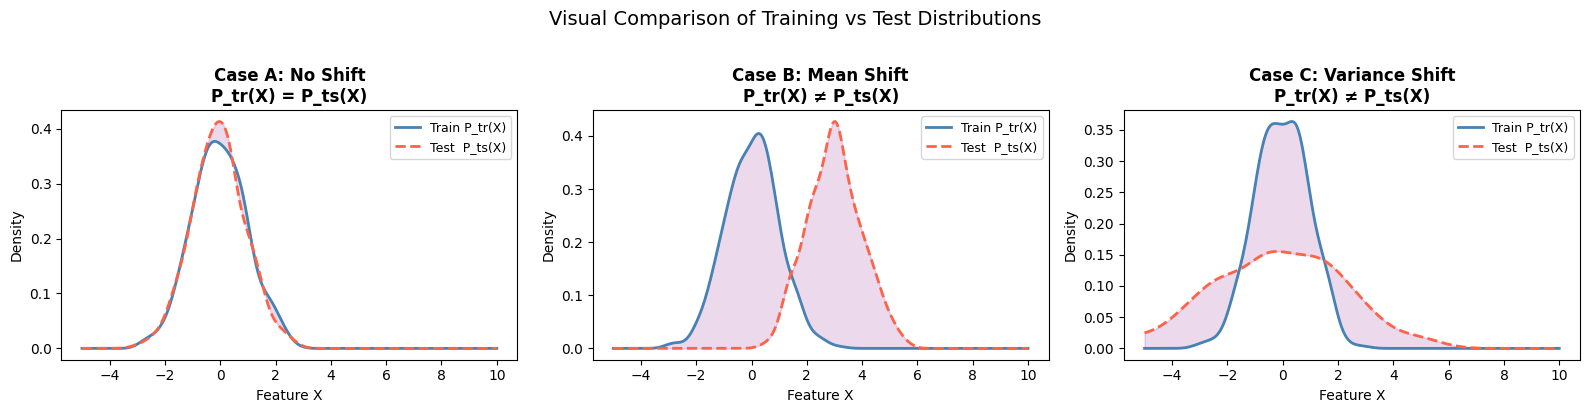

Observation: The shaded purple area represents the discrepancy between distributions.
Larger shaded area → greater dataset shift.


In [4]:
# ─── Case A: No Shift ────────────────────────────────────────────────────────
np.random.seed(0)
train_no_shift = np.random.normal(loc=0.0, scale=1.0, size=500)
test_no_shift  = np.random.normal(loc=0.0, scale=1.0, size=500)

x = np.linspace(-5, 10, 300)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

def plot_kde(ax, train, test, title):
    kde_tr = gaussian_kde(train)
    kde_ts = gaussian_kde(test)
    ax.plot(x, kde_tr(x), color='steelblue', lw=2, label='Train P_tr(X)')
    ax.plot(x, kde_ts(x), color='tomato',    lw=2, label='Test  P_ts(X)', linestyle='--')
    ax.fill_between(x, kde_tr(x), kde_ts(x), alpha=0.15, color='purple')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlabel('Feature X')
    ax.set_ylabel('Density')

# ─── Case B: Covariate Shift (mean shifts) ───────────────────────────────────
train_cov = np.random.normal(loc=0.0, scale=1.0, size=500)
test_cov  = np.random.normal(loc=3.0, scale=1.0, size=500)   # mean shifted

# ─── Case C: Variance Shift ───────────────────────────────────────────────────
train_var = np.random.normal(loc=0.0, scale=1.0, size=500)
test_var  = np.random.normal(loc=0.0, scale=2.5, size=500)   # std shifted

plot_kde(axes[0], train_no_shift, test_no_shift, 'Case A: No Shift\nP_tr(X) = P_ts(X)')
plot_kde(axes[1], train_cov,      test_cov,      'Case B: Mean Shift\nP_tr(X) ≠ P_ts(X)')
plot_kde(axes[2], train_var,      test_var,      'Case C: Variance Shift\nP_tr(X) ≠ P_ts(X)')

plt.suptitle('Visual Comparison of Training vs Test Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Observation: The shaded purple area represents the discrepancy between distributions.')
print('Larger shaded area → greater dataset shift.')

---
## Section 3 — Simulating the Three Types of Dataset Shift <a id='section3'></a>

### 3.1 Covariate Shift

**Condition**: P_tr(Y|X) = P_ts(Y|X) but P_tr(X) ≠ P_ts(X)

We simulate this by:
- Using the **same** decision boundary (same classifier) for both train and test
- Sampling X from **different** distributions at train and test time

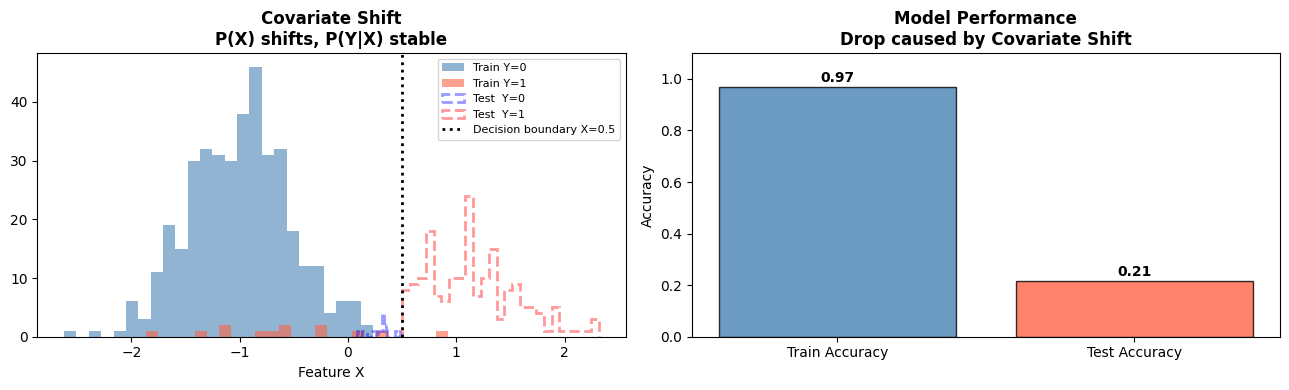

Train accuracy: 0.968
Test  accuracy: 0.215
Performance gap due to covariate shift: 0.753


In [25]:
np.random.seed(42)

# Ground truth decision boundary: Y=1 if X > 0.5, else Y=0  (same for both)
def true_label(x):
    return (x > 0.5).astype(int)

# Training: X drawn from N(-1, 0.5) — all in negative region, Y=0
X_train_cs = np.random.normal(-1, 0.5, 400)
Y_train_cs = true_label(X_train_cs) + np.random.binomial(1, 0.05, 400)  # small noise
Y_train_cs = np.clip(Y_train_cs, 0, 1)

# Test: X drawn from N(+1, 0.5) — all in positive region, Y=1 (distribution SHIFTED)
X_test_cs  = np.random.normal(+1, 0.5, 200)
Y_test_cs  = true_label(X_test_cs)

# ─── Plot ────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.hist(X_train_cs[Y_train_cs==0], bins=25, alpha=0.6, color='steelblue', label='Train Y=0')
ax1.hist(X_train_cs[Y_train_cs==1], bins=25, alpha=0.6, color='tomato',    label='Train Y=1')
ax1.hist(X_test_cs [Y_test_cs ==0], bins=25, alpha=0.4, color='blue',      label='Test  Y=0', linestyle='--', histtype='step', lw=2)
ax1.hist(X_test_cs [Y_test_cs ==1], bins=25, alpha=0.4, color='red',       label='Test  Y=1', linestyle='--', histtype='step', lw=2)
ax1.axvline(0.5, color='black', lw=2, linestyle=':', label='Decision boundary X=0.5')
ax1.set_title('Covariate Shift\nP(X) shifts, P(Y|X) stable', fontweight='bold')
ax1.legend(fontsize=8)
ax1.set_xlabel('Feature X')

# Train a simple model and observe the drop in test accuracy
clf_cs = LogisticRegression()
clf_cs.fit(X_train_cs.reshape(-1,1), Y_train_cs)
train_acc = accuracy_score(Y_train_cs, clf_cs.predict(X_train_cs.reshape(-1,1)))
test_acc  = accuracy_score(Y_test_cs,  clf_cs.predict(X_test_cs.reshape(-1,1)))

ax2.bar(['Train Accuracy', 'Test Accuracy'], [train_acc, test_acc],
        color=['steelblue', 'tomato'], alpha=0.8, edgecolor='black')
ax2.set_ylim(0, 1.1)
ax2.set_ylabel('Accuracy')
ax2.set_title('Model Performance\nDrop caused by Covariate Shift', fontweight='bold')
for i, v in enumerate([train_acc, test_acc]):
    ax2.text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Train accuracy: {train_acc:.3f}')
print(f'Test  accuracy: {test_acc:.3f}')
print(f'Performance gap due to covariate shift: {train_acc - test_acc:.3f}')

### 3.2 Concept Shift

**Condition**: P_tr(Y|X) ≠ P_ts(Y|X) but P_tr(X) = P_ts(X)

The input distribution is unchanged, but the **mapping from X to Y reverses** — the very concept being learned has changed.

This is the hardest shift to handle because re-weighting samples does not fix it.

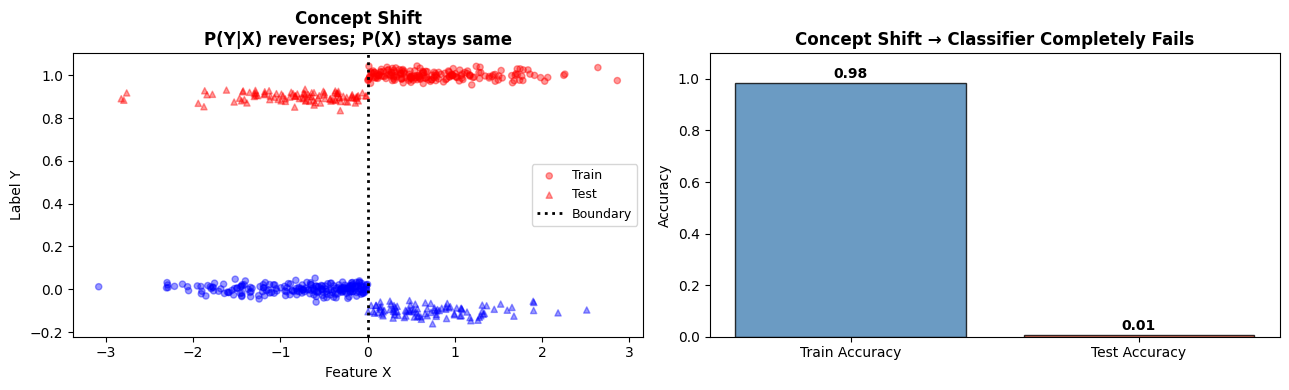

Test accuracy near 0 means the learned concept is completely wrong at test time.


In [6]:
np.random.seed(7)

# Both train and test: X drawn from the SAME distribution N(0, 1)
X_train_conc = np.random.normal(0, 1, 400)
X_test_conc  = np.random.normal(0, 1, 200)

# Training: Y=1 if X > 0  (concept A)
Y_train_conc = (X_train_conc > 0).astype(int)

# Test: Y=1 if X < 0  (concept REVERSED — concept shift!)
Y_test_conc  = (X_test_conc < 0).astype(int)

# Train and evaluate
clf_conc = LogisticRegression()
clf_conc.fit(X_train_conc.reshape(-1,1), Y_train_conc)
train_acc_c = accuracy_score(Y_train_conc, clf_conc.predict(X_train_conc.reshape(-1,1)))
test_acc_c  = accuracy_score(Y_test_conc,  clf_conc.predict(X_test_conc.reshape(-1,1)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.scatter(X_train_conc, Y_train_conc + np.random.normal(0, 0.02, len(X_train_conc)),
            c=Y_train_conc, cmap='bwr', alpha=0.4, label='Train', marker='o', s=20)
ax1.scatter(X_test_conc,  Y_test_conc  - 0.1 + np.random.normal(0, 0.02, len(X_test_conc)),
            c=Y_test_conc,  cmap='bwr', alpha=0.4, label='Test',  marker='^', s=20)
ax1.axvline(0, color='black', lw=2, linestyle=':', label='Boundary')
ax1.set_title('Concept Shift\nP(Y|X) reverses; P(X) stays same', fontweight='bold')
ax1.set_xlabel('Feature X'); ax1.set_ylabel('Label Y')
ax1.legend(fontsize=9)

ax2.bar(['Train Accuracy', 'Test Accuracy'], [train_acc_c, test_acc_c],
        color=['steelblue', 'tomato'], alpha=0.8, edgecolor='black')
ax2.set_ylim(0, 1.1); ax2.set_ylabel('Accuracy')
ax2.set_title('Concept Shift → Classifier Completely Fails', fontweight='bold')
for i, v in enumerate([train_acc_c, test_acc_c]):
    ax2.text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout(); plt.show()
print(f'Test accuracy near 0 means the learned concept is completely wrong at test time.')

---
## Section 4 — Detecting Covariate Shift Statistically <a id='section4'></a>

Two standard statistical tests for comparing distributions:

| Test | Null Hypothesis | Sensitive to |
|------|-----------------|-------------|
| **t-test** (Welch) | Means are equal | Mean shift |
| **KS test** | Both samples from same distribution | Any distributional difference |

If the p-value < significance level (e.g. 0.05) → reject null → **shift detected**.

In [26]:
from scipy.stats import ks_2samp, ttest_ind

def run_shift_tests(train, test, label='Dataset', alpha=0.05):
    """Run t-test and KS test and print interpreted results."""
    t_stat, t_pval = ttest_ind(train, test, equal_var=False)   # Welch's t-test
    ks_stat, ks_pval = ks_2samp(train, test)

    print(f'\n─── {label} ─────────────────────────────────────────')
    print(f'  Train: mean={np.mean(train):.3f}, std={np.std(train):.3f}')
    print(f'  Test : mean={np.mean(test):.3f},  std={np.std(test):.3f}')
    print(f'  Welch t-test  → p={t_pval:.4f}  | Shift: {"YES ⚠️" if t_pval < alpha else "no ✓"}')
    print(f'  KS test       → p={ks_pval:.4f}  | Shift: {"YES ⚠️" if ks_pval < alpha else "no ✓"}')

np.random.seed(0)

# ─── Experiment 1: No shift ────────────────────────────────────────────────
run_shift_tests(
    np.random.normal(0, 1, 300),
    np.random.normal(0, 1, 300),
    label='Experiment 1: No Shift  [N(0,1) vs N(0,1)]'
)

# ─── Experiment 2: Mean shift ──────────────────────────────────────────────
run_shift_tests(
    np.random.normal(0, 1, 300),
    np.random.normal(2, 1, 300),
    label='Experiment 2: Mean Shift [N(0,1) vs N(2,1)]'
)

# ─── Experiment 3: Variance shift (t-test misses it) ──────────────────────
run_shift_tests(
    np.random.normal(0, 1.0, 300),
    np.random.normal(0, 3.0, 300),
    label='Experiment 3: Variance Shift [N(0,1) vs N(0,3)]'
)

print('\n💡 Key insight: The KS test detects variance shifts that the t-test misses.')
print('   Always use the KS test when you suspect any form of distributional shift.')


─── Experiment 1: No Shift  [N(0,1) vs N(0,1)] ─────────────────────────────────────────
  Train: mean=0.028, std=1.001
  Test : mean=-0.137,  std=1.000
  Welch t-test  → p=0.0442  | Shift: YES ⚠️
  KS test       → p=0.2488  | Shift: no ✓

─── Experiment 2: Mean Shift [N(0,1) vs N(2,1)] ─────────────────────────────────────────
  Train: mean=-0.096, std=0.960
  Test : mean=2.119,  std=0.929
  Welch t-test  → p=0.0000  | Shift: YES ⚠️
  KS test       → p=0.0000  | Shift: YES ⚠️

─── Experiment 3: Variance Shift [N(0,1) vs N(0,3)] ─────────────────────────────────────────
  Train: mean=-0.015, std=0.990
  Test : mean=0.057,  std=2.989
  Welch t-test  → p=0.6914  | Shift: no ✓
  KS test       → p=0.0000  | Shift: YES ⚠️

💡 Key insight: The KS test detects variance shifts that the t-test misses.
   Always use the KS test when you suspect any form of distributional shift.


---
## Section 5 — Correcting Covariate Shift with Importance Weighting <a id='section5'></a>

When covariate shift is present, we can correct for it by **re-weighting** the training samples.

Each training sample x receives a weight:

$$w(x) = \frac{P_{\text{ts}}(x)}{P_{\text{tr}}(x)}$$

**Intuition:** A training sample that is rare under P_tr but common under P_ts should count more. Its high weight forces the learner to pay more attention to it.

We estimate both densities using **Kernel Density Estimation (KDE)**.

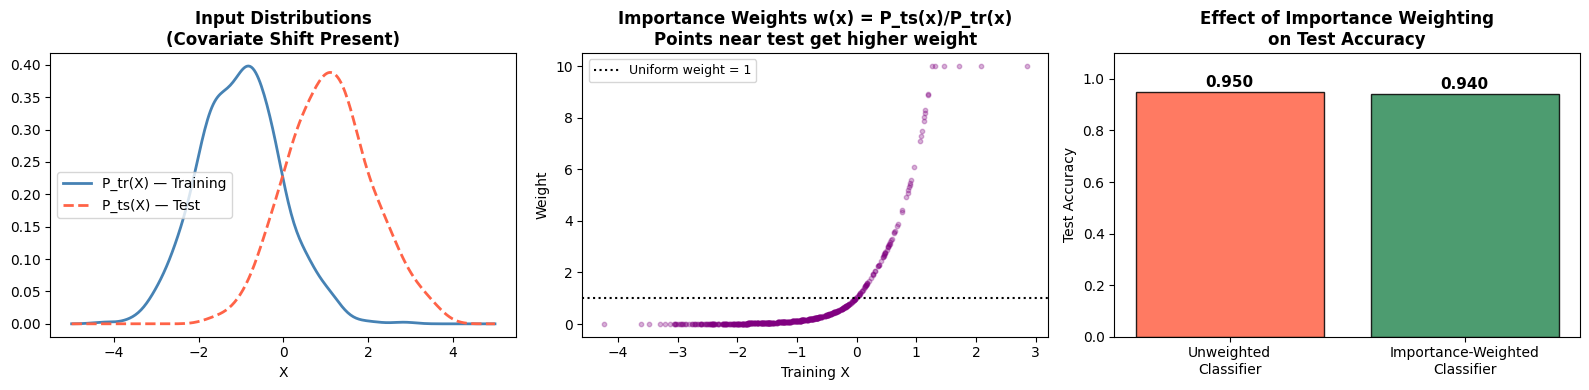

Unweighted accuracy: 0.950
Weighted   accuracy: 0.940
Improvement from importance weighting: -0.010


In [27]:
np.random.seed(42)

# ── Generate data with covariate shift ──────────────────────────────────────
X_train = np.random.normal(-1, 1, 600)          # Training: shifted left
Y_train = (X_train + np.random.normal(0, 0.3, 600) > 0).astype(int)

X_test  = np.random.normal(+1, 1, 300)          # Test: shifted right
Y_test  = (X_test  + np.random.normal(0, 0.3, 300) > 0).astype(int)

# ── Estimate importance weights using KDE ───────────────────────────────────
kde_train = gaussian_kde(X_train)
kde_test  = gaussian_kde(X_test)

# Evaluate densities at each training point
p_tr = kde_train(X_train)
p_ts = kde_test(X_train)

# Importance weights with clipping to prevent numerical instability
weights = np.clip(p_ts / (p_tr + 1e-10), 0.01, 10.0)

# ── Train two classifiers: unweighted vs importance-weighted ────────────────
scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train.reshape(-1,1))
X_ts_sc = scaler.transform(X_test.reshape(-1,1))

clf_unweighted = LogisticRegression()
clf_unweighted.fit(X_tr_sc, Y_train)

clf_weighted = LogisticRegression()
clf_weighted.fit(X_tr_sc, Y_train, sample_weight=weights)

acc_unweighted = accuracy_score(Y_test, clf_unweighted.predict(X_ts_sc))
acc_weighted   = accuracy_score(Y_test, clf_weighted.predict(X_ts_sc))

# ── Visualise ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

x_range = np.linspace(-5, 5, 300)
axes[0].plot(x_range, kde_train(x_range), color='steelblue', lw=2, label='P_tr(X) — Training')
axes[0].plot(x_range, kde_test(x_range),  color='tomato',    lw=2, label='P_ts(X) — Test', ls='--')
axes[0].set_title('Input Distributions\n(Covariate Shift Present)', fontweight='bold')
axes[0].legend(); axes[0].set_xlabel('X')

axes[1].scatter(X_train, weights, alpha=0.3, s=10, c='purple')
axes[1].axhline(1.0, color='black', ls=':', lw=1.5, label='Uniform weight = 1')
axes[1].set_title('Importance Weights w(x) = P_ts(x)/P_tr(x)\nPoints near test get higher weight', fontweight='bold')
axes[1].set_xlabel('Training X'); axes[1].set_ylabel('Weight')
axes[1].legend(fontsize=9)

axes[2].bar(['Unweighted\nClassifier', 'Importance-Weighted\nClassifier'],
            [acc_unweighted, acc_weighted],
            color=['tomato', 'seagreen'], alpha=0.85, edgecolor='black')
axes[2].set_ylim(0, 1.1); axes[2].set_ylabel('Test Accuracy')
axes[2].set_title('Effect of Importance Weighting\non Test Accuracy', fontweight='bold')
for i, v in enumerate([acc_unweighted, acc_weighted]):
    axes[2].text(i, v+0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout(); plt.show()
print(f'Unweighted accuracy: {acc_unweighted:.3f}')
print(f'Weighted   accuracy: {acc_weighted:.3f}')
print(f'Improvement from importance weighting: {acc_weighted - acc_unweighted:+.3f}')

---
## Section 6 — Transfer Learning: Feature Extraction with a Pre-trained Model <a id='section6'></a>

### The Core Idea

A ConvNet trained on ImageNet (1.2M images, 1000 classes) has learned rich hierarchical visual representations:

- **Early layers**: edges, corners, colour blobs (very generic — transfer well)
- **Middle layers**: textures, patterns, object parts
- **Late layers**: task-specific features (less transferable)

We can **cut off** the task-specific head and use the remaining layers as a fixed feature extractor.

### Strategy A: ConvNet as Fixed Feature Extractor

```
ImageNet-Trained VGG-16
────────────────────────────────────────────────
[Conv Blocks 1–5]  →  FREEZE (do not update)
[FC1: 4096]        →  FREEZE
[FC2: 4096]        →  FREEZE
[Softmax: 1000]    →  REMOVE

  ↓ extract 4096-D feature vector for each image

[New Classifier]   →  TRAIN on your data
────────────────────────────────────────────────
```

Below we **simulate** this pipeline using a small synthetic image dataset, since loading VGG-16 requires downloading weights (~500MB). The key concepts are identical.

Strategy A: ConvNet as Fixed Feature Extractor
───────────────────────────────────────────────────────
  [Small dataset]  Train samples:   72 | Test Accuracy: 0.556
  [Large dataset]  Train samples:  720 | Test Accuracy: 0.867


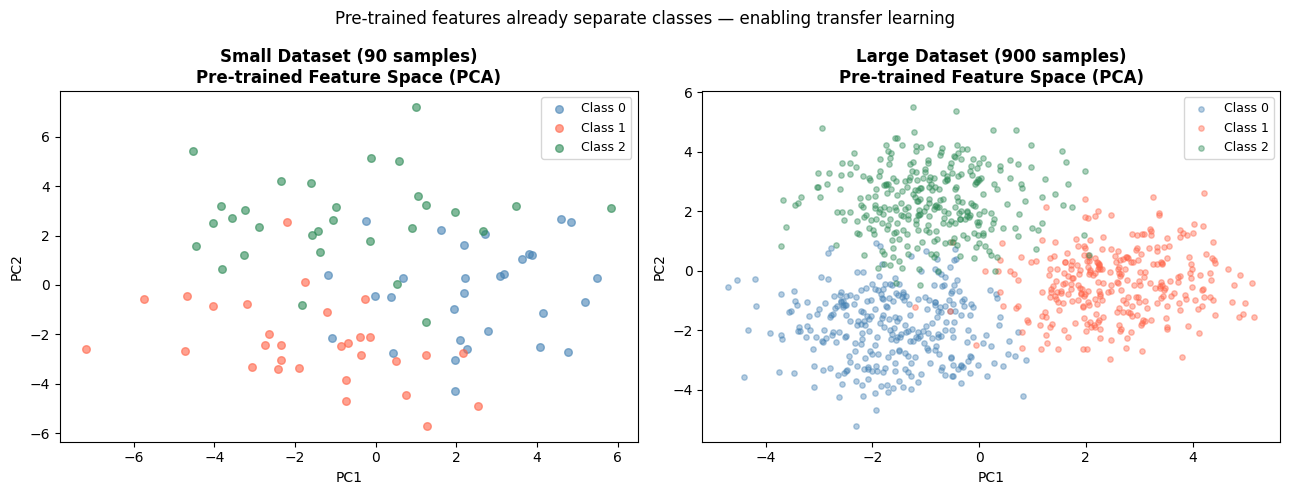

In [28]:
# ── Simulate a pre-trained feature extractor ─────────────────────────────────
# In a real pipeline: load VGG16(include_top=False, weights='imagenet')
# and call model.predict(images) to extract features.
# Here we simulate the extracted feature vectors.

np.random.seed(42)

def simulate_pretrained_features(n_samples, n_features=256, n_classes=3):
    """
    Simulate features as would be extracted by a pre-trained ConvNet.
    Each class has a distinct cluster in feature space — this is the key
    assumption of transfer learning: the pre-trained representations are
    already discriminative for the new task.
    """
    class_means = np.eye(n_classes, n_features) * 3   # each class at a distinct point
    X, y = [], []
    for cls in range(n_classes):
        n = n_samples // n_classes
        features = np.random.normal(class_means[cls], 1.0, (n, n_features))
        X.append(features)
        y.extend([cls] * n)
    return np.vstack(X), np.array(y)

# Simulate two target datasets of different sizes
X_small, y_small = simulate_pretrained_features(n_samples=90,  n_features=256)
X_large, y_large = simulate_pretrained_features(n_samples=900, n_features=256)

# Split into train/test (80/20)
from sklearn.model_selection import train_test_split

Xtr_s, Xts_s, ytr_s, yts_s = train_test_split(X_small, y_small, test_size=0.2, random_state=0)
Xtr_l, Xts_l, ytr_l, yts_l = train_test_split(X_large, y_large, test_size=0.2, random_state=0)

# ── Strategy A: Linear classifier on top of frozen features ─────────────────
from sklearn.svm import LinearSVC

def train_linear_on_features(X_train, y_train, X_test, y_test, label):
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_train)
    Xts = scaler.transform(X_test)
    clf = LinearSVC(max_iter=2000)
    clf.fit(Xtr, y_train)
    acc = accuracy_score(y_test, clf.predict(Xts))
    print(f'  [{label}]  Train samples: {len(X_train):4d} | Test Accuracy: {acc:.3f}')
    return acc

print('Strategy A: ConvNet as Fixed Feature Extractor')
print('─' * 55)
acc_s = train_linear_on_features(Xtr_s, ytr_s, Xts_s, yts_s, 'Small dataset')
acc_l = train_linear_on_features(Xtr_l, ytr_l, Xts_l, yts_l, 'Large dataset')

# ── Visualise feature space (2 PCA dims) ─────────────────────────────────────
from sklearn.decomposition import PCA

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

pca = PCA(n_components=2, random_state=0)
X2d_s = pca.fit_transform(X_small)
X2d_l = pca.fit_transform(X_large)

colors = ['steelblue', 'tomato', 'seagreen']
for cls in range(3):
    ax1.scatter(X2d_s[y_small==cls, 0], X2d_s[y_small==cls, 1],
                c=colors[cls], alpha=0.6, s=30, label=f'Class {cls}')
    ax2.scatter(X2d_l[y_large==cls, 0], X2d_l[y_large==cls, 1],
                c=colors[cls], alpha=0.4, s=15, label=f'Class {cls}')

ax1.set_title('Small Dataset (90 samples)\nPre-trained Feature Space (PCA)', fontweight='bold')
ax2.set_title('Large Dataset (900 samples)\nPre-trained Feature Space (PCA)', fontweight='bold')
for ax in [ax1, ax2]:
    ax.legend(fontsize=9); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.suptitle('Pre-trained features already separate classes — enabling transfer learning', fontsize=12)
plt.tight_layout(); plt.show()

### Strategy B: Fine-tuning

Instead of freezing all layers, we unfreeze some and continue training with a **small learning rate**.

The pseudocode below shows how you would do this in Keras (this cell is illustrative — no GPU required):

```python
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model

# Load pre-trained VGG16 without the classification head
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# ── Strategy A: Freeze ALL base layers ──────────────────────
for layer in base_model.layers:
    layer.trainable = False

# ── Strategy B: Unfreeze top N layers for fine-tuning ───────
N_unfreeze = 4   # unfreeze last 4 layers
for layer in base_model.layers[-N_unfreeze:]:
    layer.trainable = True

# Add new classification head
x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile with a SMALL learning rate to preserve pre-trained weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(train_dataset, epochs=10, validation_data=val_dataset)
```

> **Why a small learning rate?**  
> The pre-trained weights already encode rich features. A large learning rate would destroy them. A small rate (e.g. 1e-4 vs the usual 1e-3) gently adapts the weights to the new task without catastrophic forgetting.

---
## Section 7 — Choosing a Transfer Learning Strategy <a id='section7'></a>

The lecture provides a clear decision framework. Let's visualise it interactively.

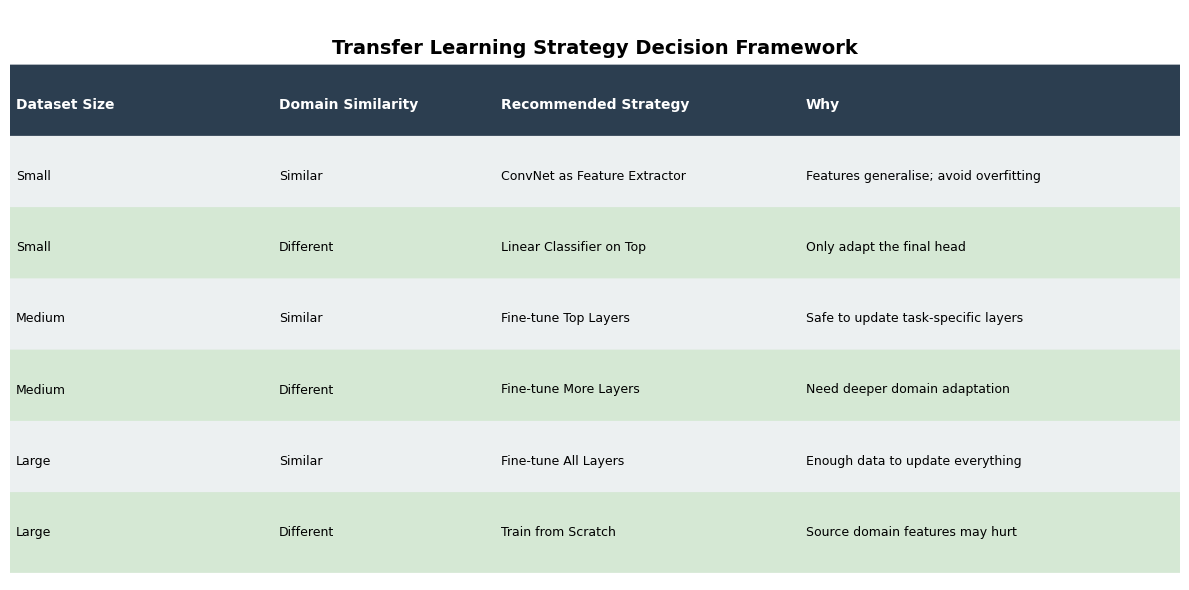

Memorise this table — it will help you in the graded quiz!


In [29]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis('off')

# Table header
ax.text(5, 5.6, 'Transfer Learning Strategy Decision Framework',
        ha='center', va='center', fontsize=14, fontweight='bold')

table_data = [
    ('Dataset Size', 'Domain Similarity', 'Recommended Strategy', 'Why'),
    ('Small',  'Similar',   'ConvNet as Feature Extractor', 'Features generalise; avoid overfitting'),
    ('Small',  'Different', 'Linear Classifier on Top',     'Only adapt the final head'),
    ('Medium', 'Similar',   'Fine-tune Top Layers',         'Safe to update task-specific layers'),
    ('Medium', 'Different', 'Fine-tune More Layers',        'Need deeper domain adaptation'),
    ('Large',  'Similar',   'Fine-tune All Layers',         'Enough data to update everything'),
    ('Large',  'Different', 'Train from Scratch',           'Source domain features may hurt'),
]

row_colors = ['#2c3e50', '#ecf0f1', '#d5e8d4', '#ecf0f1', '#d5e8d4', '#ecf0f1', '#d5e8d4']
text_colors = ['white'] + ['black'] * 6
col_positions = [0.05, 2.3, 4.2, 6.8]
row_height = 0.75

for r, (row, bg, tc) in enumerate(zip(table_data, row_colors, text_colors)):
    y = 5.0 - r * row_height
    rect = mpatches.FancyBboxPatch((0, y - row_height/2), 10, row_height,
                                    boxstyle='round,pad=0.05', linewidth=0,
                                    facecolor=bg, transform=ax.transData)
    ax.add_patch(rect)
    for c_idx, (cell, x) in enumerate(zip(row, col_positions)):
        fw = 'bold' if r == 0 else 'normal'
        fs = 9 if r > 0 else 10
        ax.text(x, y, cell, ha='left', va='center', fontsize=fs,
                fontweight=fw, color=tc, transform=ax.transData)

plt.tight_layout(); plt.show()
print('Memorise this table — it will help you in the graded quiz!')

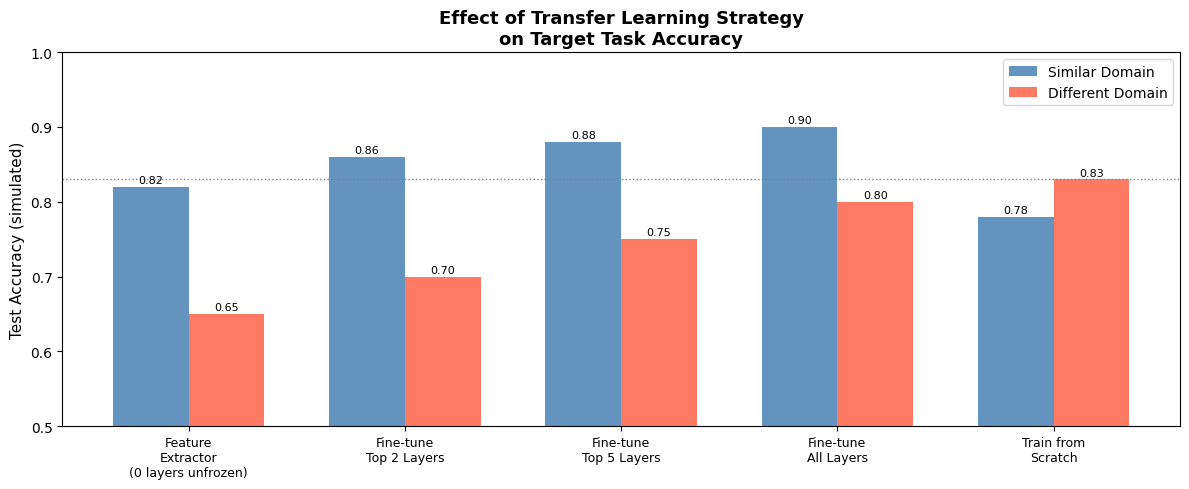

Takeaway: For similar domains, a feature extractor is already powerful.
For different domains, you need to fine-tune deeper or train from scratch.


In [30]:
# ── Simulated comparison: fine-tuning more vs fewer layers ──────────────────
# We simulate accuracy gains from unfreezing progressively more layers

np.random.seed(5)

strategies = [
    'Feature\nExtractor\n(0 layers unfrozen)',
    'Fine-tune\nTop 2 Layers',
    'Fine-tune\nTop 5 Layers',
    'Fine-tune\nAll Layers',
    'Train from\nScratch'
]

# Simulated accuracies for: (a) similar domain, (b) very different domain
# Values represent expected behaviour described in the literature
acc_similar   = [0.82, 0.86, 0.88, 0.90, 0.78]   # Fine-tuning helps
acc_different = [0.65, 0.70, 0.75, 0.80, 0.83]   # Need more layers / from scratch

x = np.arange(len(strategies))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, acc_similar,   width, label='Similar Domain',   color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, acc_different, width, label='Different Domain', color='tomato',    alpha=0.85)

ax.set_ylabel('Test Accuracy (simulated)', fontsize=11)
ax.set_title('Effect of Transfer Learning Strategy\non Target Task Accuracy', fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(strategies, fontsize=9)
ax.set_ylim(0.5, 1.0)
ax.legend(fontsize=10)
ax.axhline(0.83, color='grey', ls=':', lw=1, label='Random baseline')

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.2f}', ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.2f}', ha='center', fontsize=8)

plt.tight_layout(); plt.show()
print('Takeaway: For similar domains, a feature extractor is already powerful.')
print('For different domains, you need to fine-tune deeper or train from scratch.')

---
## Section 8 — Practice Exercises <a id='section8'></a>

> These exercises cover the **same concepts** as the graded quiz but with **different implementations**. Complete all of them before attempting the quiz.

---

### Exercise 1: Compute KL Divergence Between Two Distributions

The Kullback-Leibler (KL) divergence is a measure of how different two probability distributions P and Q are. It is defined as:

$$D_{KL}(P \| Q) = \sum_{i} P(i) \log \frac{P(i)}{Q(i)}$$

A KL divergence of 0 means the distributions are identical; larger values indicate greater shift.

**Task**: Implement `kl_divergence(p, q)` where `p` and `q` are probability distributions (numpy arrays summing to 1). Add a small epsilon (1e-10) to both before computing to avoid log(0).

In [33]:
import numpy as np

def kl_divergence(p, q, epsilon=1e-10):
    """
    Compute KL divergence KL(P || Q).
    Args:
        p, q    : 1-D numpy arrays, probability distributions (sum to 1)
        epsilon : small value to avoid log(0)
    Returns:
        float: KL divergence
    """
    # TODO: implement KL divergence
    # Hint: add epsilon to p and q before computing

    return


# ── Test your implementation ────────────────────────────────────────────────
p = np.array([0.4, 0.35, 0.25])
q = np.array([0.4, 0.35, 0.25])  # same → KL should be ~0
print(f'KL(P||P) = {kl_divergence(p, q):.6f}   (expected: ~0)')

p2 = np.array([0.5, 0.3, 0.2])
q2 = np.array([0.1, 0.6, 0.3])  # different → KL should be > 0
print(f'KL(P||Q) = {kl_divergence(p2, q2):.6f}  (expected: > 0)')

print(f'KL(Q||P) = {kl_divergence(q2, p2):.6f}  (note: KL is NOT symmetric)')

KL(P||P) = 0.000000   (expected: ~0)
KL(P||Q) = 0.515682  (expected: > 0)
KL(Q||P) = 0.376584  (note: KL is NOT symmetric)


In [ ]:
# ── SOLUTION (run after attempting) ─────────────────────────────────────────
def kl_divergence(p, q, epsilon=1e-10):
    p = np.array(p, dtype=float) + epsilon
    q = np.array(q, dtype=float) + epsilon
    return float(np.sum(p * np.log(p / q)))

p = np.array([0.4, 0.35, 0.25])
q = np.array([0.4, 0.35, 0.25])
assert abs(kl_divergence(p, q)) < 1e-6, 'Same distributions should give KL ≈ 0'

p2 = np.array([0.5, 0.3, 0.2])
q2 = np.array([0.1, 0.6, 0.3])
assert kl_divergence(p2, q2) > 0, 'Different distributions should give KL > 0'
print('✓ Exercise 1 solution verified')

---
### Exercise 2: Normalise Importance Weights

Raw importance weights w(x) = P_ts(x) / P_tr(x) can be unstable. A common practice is to **normalise** them so they sum to the number of training samples:

$$\tilde{w}_i = \frac{w_i}{\frac{1}{n}\sum_{j=1}^{n} w_j} = \frac{n \cdot w_i}{\sum_{j=1}^{n} w_j}$$

**Task**: Implement `normalise_weights(weights)` that normalises a numpy array of raw importance weights.

In [ ]:
def normalise_weights(weights):
    """
    Normalise importance weights so their mean equals 1.
    Args:
        weights: 1-D array-like of non-negative importance weights
    Returns:
        numpy.ndarray: normalised weights with mean == 1.0
    """
    # TODO: implement normalisation
    pass


# ── Test your implementation ─────────────────────────────────────────────────
raw_w = np.array([0.5, 2.0, 1.5, 0.3, 3.2, 0.8])
norm_w = normalise_weights(raw_w)
print(f'Raw weights:        {raw_w}')
print(f'Normalised weights: {norm_w}')
print(f'Mean of normalised: {np.mean(norm_w):.6f}  (should be 1.0)')
print(f'Sum of normalised:  {np.sum(norm_w):.6f}  (should be {len(raw_w)})')

---
### Exercise 3: Count Trainable Parameters in a Layer Configuration

When deciding how many layers to fine-tune, it helps to know how many parameters each layer contains.

For a fully-connected (Dense) layer with `n_in` inputs and `n_out` outputs:

$$\text{params} = n_{\text{in}} \times n_{\text{out}} + n_{\text{out}} \quad (\text{weights + biases})$$

**Task**: Implement `count_dense_params(layer_sizes)` where `layer_sizes` is a list of integers `[input_dim, h1, h2, ..., output_dim]`. Return the total number of trainable parameters across all layers.

In [ ]:
def count_dense_params(layer_sizes):
    """
    Count the total trainable parameters in a fully-connected network.
    Args:
        layer_sizes: list of ints, e.g. [4096, 256, 10] means one hidden
                     layer of 256 units and an output of 10 units.
    Returns:
        int: total number of parameters (weights + biases)
    """
    # TODO: implement
    # Hint: iterate over consecutive pairs in layer_sizes
    pass


# ── Test ─────────────────────────────────────────────────────────────────────
# VGG-16 classifier head: 4096 → 4096 → 1000
vgg_head = [4096, 4096, 1000]
print(f'VGG-16 classifier head params: {count_dense_params(vgg_head):,}')

# Simple network: 10 inputs → 5 hidden → 2 outputs
simple_net = [10, 5, 2]
expected = (10*5 + 5) + (5*2 + 2)   # = 55 + 12 = 67
print(f'Simple network params: {count_dense_params(simple_net)}  (expected: {expected})')

---
### Exercise 4: Compute Per-Class Prior Probabilities

Prior probability shift is defined as a change in P(Y). To monitor for this type of shift, we need to compute and compare the prior probabilities of each class in training vs test sets.

**Task**: Implement `compute_priors(labels)` that returns a dictionary mapping each unique class label to its proportion in `labels`.

In [ ]:
def compute_priors(labels):
    """
    Compute prior probabilities P(Y=c) for each class c.
    Args:
        labels: list or array of integer class labels
    Returns:
        dict: {class_label: probability} where probabilities sum to 1.0
    """
    # TODO: implement
    pass


# ── Test ─────────────────────────────────────────────────────────────────────
train_labels = [0, 0, 0, 1, 1, 2]         # imbalanced
test_labels  = [0, 1, 1, 1, 2, 2, 2, 2]   # different priors

train_priors = compute_priors(train_labels)
test_priors  = compute_priors(test_labels)

print('Training priors:', {k: f'{v:.3f}' for k, v in train_priors.items()})
print('Test priors    :', {k: f'{v:.3f}' for k, v in test_priors.items()})

# Visualise prior shift
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
classes = sorted(train_priors.keys())
ax1.bar(classes, [train_priors.get(c, 0) for c in classes], color='steelblue', alpha=0.8)
ax2.bar(classes, [test_priors.get(c, 0)  for c in classes], color='tomato',    alpha=0.8)
ax1.set_title('Training Priors P_tr(Y)', fontweight='bold'); ax1.set_ylabel('P(Y=c)')
ax2.set_title('Test Priors P_ts(Y)', fontweight='bold');     ax2.set_ylabel('P(Y=c)')
for ax in [ax1, ax2]: ax.set_xlabel('Class'); ax.set_ylim(0, 0.8)
plt.suptitle('Prior Probability Shift: P_tr(Y) ≠ P_ts(Y)', fontweight='bold')
plt.tight_layout(); plt.show()

---
### Exercise 5: Monitor Shift Over Time (Sliding Window)

In production systems, dataset shift often develops **gradually** over time. A common monitoring approach is a **sliding window**: compare a fixed reference window (training distribution) against a rolling test window of recent samples.

**Task**: Implement `sliding_window_shift_scores(reference, stream, window_size)` that slides a window over `stream`, computing the absolute difference in means between the reference distribution and each window. Return a list of scores (one per window position).

In [ ]:
def sliding_window_shift_scores(reference, stream, window_size):
    """
    Compute drift scores over a data stream using a sliding window.
    Args:
        reference   : 1-D array-like, the reference (training) distribution
        stream      : 1-D array-like, incoming data stream
        window_size : int, size of the sliding window
    Returns:
        list of float: |mean(window) - mean(reference)| for each window position
    """
    # TODO: implement
    # Hint: iterate from 0 to len(stream) - window_size + 1
    pass


# ── Simulate a data stream with a sudden concept drift at t=150 ──────────────
np.random.seed(0)
reference   = np.random.normal(0, 1, 200)
stream_pre  = np.random.normal(0, 1, 150)       # same distribution
stream_post = np.random.normal(3, 1, 150)       # sudden shift at t=150
stream = np.concatenate([stream_pre, stream_post])

scores = sliding_window_shift_scores(reference, stream, window_size=30)

if scores is not None:
    plt.figure(figsize=(12, 4))
    plt.plot(scores, color='steelblue', lw=2)
    plt.axvline(150 - 30, color='red', lw=2, ls='--', label='Shift begins at t=150')
    plt.axhline(0.5, color='orange', lw=1.5, ls=':', label='Alert threshold')
    plt.fill_between(range(len(scores)), scores, alpha=0.2, color='steelblue')
    plt.title('Sliding Window Drift Monitoring\n|mean(window) - mean(reference)|',
              fontweight='bold')
    plt.xlabel('Time step'); plt.ylabel('Drift Score')
    plt.legend(); plt.tight_layout(); plt.show()
    print(f'Max drift score: {max(scores):.3f}')
    print(f'Score before drift (t=100): {scores[100]:.3f}')
    print(f'Score after  drift (t=160): {scores[160]:.3f}')

---

## Conclusion

- Visualised and simulated the three types of dataset shift
- Applied statistical tests (t-test, KS test) to detect shift
- Implemented and applied importance weighting to correct for covariate shift
- Explored the transfer learning feature extraction pipeline
- Practised five coding exercises covering KL divergence, weight normalisation, parameter counting, prior computation, and drift monitoring

### Next step

Head to **Moodle → Lab 09 Quiz** and attempt the **5 graded CodeRunner questions**.

---